# Princing e Descontos em Eventos: Uma Análise de Dados para Apoio à Decisão Comercial

# Introdução

Este trabalho tem como objetivo analisar os dados de vendas de stands do evento Exagerado (meu estágio), com foco em entender os principais fatores que impactam a receita total e o atingimento da meta comercial estabelecida.

A receita de vendas de stands depende fundamentalmente de três fatores: o preço por metro quadrado, a área vendida e os descontos condedidos nas negociações. Dessa forma, para entender o desempenho comercial do evento, é necessário analisar como cada um desses fatores se comporta nos dados reais de vendas.

A partir de uma análise exploratória inicial realizada em um dashboard, observou-se que os descontos concedidos representam uma parcela pequena da receita total, indicando que eles provavelmente não são o principal fator responsável por diferenças entre a receita prevista, realizada e a meta estabelecida.

Além disso, o preço médio por metro quadrado realizado se mostrou relativamente próximo do preço previsto, sugerindo que a precificação dos espaços não apresenta grandes desvios entre o planejado e o executado.

Dessa forma, a análise passa a focar principalmente na relação entre preço médio por metro quadrado, área vendida e área disponível, com o objetivo de entender se a meta de receita estabelecida é compatível com a realidade de preços e ocupação do evento, além de identificar possíveis alavancas para aumento de receita em eventos futuros

# Problema de Negócio

A empresa realiza a venda de espaços para expositores em eventos, onde o valor de cada venda é determinado principalmente pela área contratada e pelo preço por metro quadrado negociado.

Para o evento analisado, foi estabelecida uma meta de receita total com a venda de stands. No entanto, ao longo do período de vendas, observou-se que a receita realizada estava abaixo da meta, o que levanta a necessidade de entender os motivos dessa diferença.

Entre os fatores que podem impactar a receita estão:
 - Descontos concedidos nas negociações;
 - Preço médio por metro quadrado praticado;
 - Área total vendida;
 - Taxa de ocupação (vacância de espaços);
 - Mix de tamanhos e localizações de stands vendidos.

Dessa forma, este projeto tem como objetivo analisar os dados de vendas de stands para responder às seguintes perguntas:
 - Os descontos concedidos impactam signficativamente a receita?
 - O preço médio por metro quadrado está alinhado com o esperado?
 - A vacância de espaços impacta a receita de forma relevante?
 - A meta de receita é compatível com o preço médio e a área disponível?
 - Quais ações poderiam aumentar a receita em eventos futuros?

A partir dessas análises, espera-se identificar os principais fatores que influenciam a receita do evento e propor possíveis melhorias na estratégia comercial e na definição de metas. 

# Análise Exploratória

Nessa seção vamos importar os dados que vamos usar, tratar e explorar nossas variáveis que podem responder nossas perguntas.

## Os descontos concedidos impactam signficativamente a receita?

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

DB_URI = os.getenv("DB_URI")
engine = create_engine(DB_URI)

query = "SELECT * FROM expositores_atual WHERE pipeline = 'ES_MAIO_26' AND tipo = 'STAND' and nome_fantasia != 'VACÂNCIA'"

df = pd.read_sql(query, engine)
df = df[df["receita_realizada"].notna()]

df["desconto"] = df["receita_prevista"] - df["receita_realizada"]
df["preco_m2"] = df["receita_realizada"] / df["area"]
df["percentual_desconto"] = df["desconto"] / df["receita_prevista"] 


df = df[(df['percentual_desconto'] != 1) & (df['percentual_desconto'] >= 0)]
df[["preco_m2", "percentual_desconto"]].describe()

,preco_m2,percentual_desconto
count,135.000000,135.000000
mean,562.581663,0.013911
std,84.726865,0.036386
min,87.719298,0.000000
25%,552.000000,0.000000
50%,552.000000,0.000000
75%,552.000000,0.000000
max,1007.400000,0.204666


In [2]:
(df["desconto"] > 0).sum()

np.int64(22)

Vemos algumas estatísticas rápidas que são do nosso interesse.

A média do preço do metro quadrado é de R$ 562, enquanto que para o percentual de descontos aplicados é de aproximadamente 1,4%

O menor valor de m2 vendido foi pouco menos de R$ 90, isso é aproximadamente R$ 470 abaixo da média.

A política de desconto é bem rigorosa, onde a esmagadora maioria dos clientes não recebem desconto, temos apenas 22 casos onde foram aplica algum tipo de desconto, sendo o maior deles de 20%.

Vamos tentar descobrir onde estamos dando desconto.

In [3]:
df_descontos = df[df["percentual_desconto"] > 0]
df_descontos.head()

,id_expositor,nome_fantasia,evento,tipo,pipeline,area,receita_realizada,receita_prevista,desconto,to_dentro,recorrente,contrato_assinado,contrato_enviado,cidade,categoria,hash,snapshot,preco_m2,percentual_desconto
8,ESPÍRITO SANTO|APOLO EYEWEAR,APOLO EYEWEAR,ESPÍRITO SANTO,STAND,ES_MAIO_26,15.0,7700.4,8280.0,579.6,True,True,True,True,SERRA,ÓCULOS DE SOL,f65f043b48f6d9ee3c870fa5ef6ead06bc29da4fa7422e...,2026-03-31 16:37:03.798707+00:00,513.36,0.070000
12,ESPÍRITO SANTO|ARRIVATA,ARRIVATA,ESPÍRITO SANTO,STAND,ES_MAIO_26,20.0,10488.0,11040.0,552.0,True,True,False,True,VITORIA,"COMÉRCIO DE BOLSAS, MOCHILAS E TÉRMICOS",28c23a488510ab0e923af9cfe6b59fa408af9cf884a055...,2026-03-31 16:37:03.798707+00:00,524.40,0.050000
15,ESPÍRITO SANTO|ART PÉ CALÇADOS,ART PÉ CALÇADOS,ESPÍRITO SANTO,STAND,ES_MAIO_26,50.0,24000.0,27600.0,3600.0,True,True,True,True,VITORIA,CALÇADOS E BOLSAS MULTIMARCAS,82a5622f9adcafdee06f7da8c9a3ddeb7618ec918d458d...,2026-03-31 16:37:03.798707+00:00,480.00,0.130435
16,ESPÍRITO SANTO|ASTERIX SUPLEMENTOS,ASTERIX SUPLEMENTOS,ESPÍRITO SANTO,STAND,ES_MAIO_26,40.0,26266.0,28796.0,2530.0,True,True,True,True,VILA VELHA,SUPLEMENTOS,bdaec0230e9f79a20ea23dcf5c1c48190aef7360235520...,2026-03-31 16:37:03.798707+00:00,656.65,0.087859
18,ESPÍRITO SANTO|BALOO BABY KIDS TEENS,BALOO BABY KIDS TEENS,ESPÍRITO SANTO,STAND,ES_MAIO_26,24.0,11520.0,13248.0,1728.0,True,True,False,True,JARDIM CAMBURI,MULTIMARCAS INFANTIL,a11babd3b196d1e63bfe819c7be7d41604ad47db37c651...,2026-03-31 16:37:03.798707+00:00,480.00,0.130435


Podemos analisar a relação de descontos e receita realizada/ valor m2 e a média da receita realizada / valor m2 para expositores com desconto e sem desconto.

Text(0.5, 1.0, 'Relação entre Receita Realizada e Desconto')

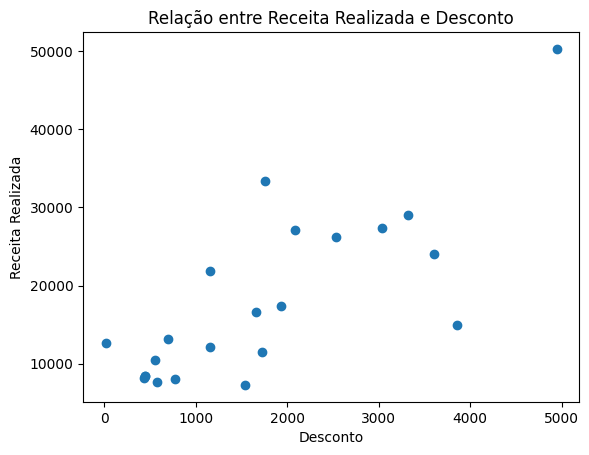

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df_descontos["desconto"], df_descontos["receita_realizada"])
plt.xlabel("Desconto")
plt.ylabel("Receita Realizada")
plt.title("Relação entre Receita Realizada e Desconto")

Pelo gráfico vimos que existe uma relação, sim, dos descontos e a receita realizada, porém não sabemos se a proporção do desconto é a mesma ou não, vamos analisar essa questão

Text(0.5, 1.0, 'Relação entre Receita Realizada e Percentual de Desconto')

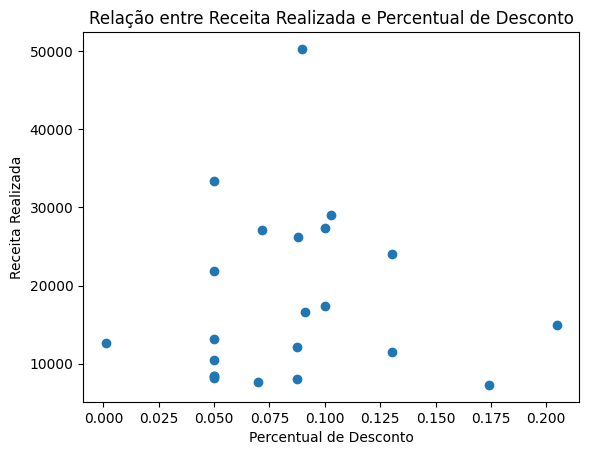

In [5]:
plt.scatter(df_descontos["percentual_desconto"], df_descontos["receita_realizada"])
plt.xlabel("Percentual de Desconto")
plt.ylabel("Receita Realizada")
plt.title("Relação entre Receita Realizada e Percentual de Desconto")

Vemos que, de fato, não há muita correlação do percentual de desconto na receita realizada, podemos checar se a distribuição é mais compactada, o que significaria que a política de descontos segue aproximadamente na mesma proporção para todos concedidos com desconto.

Os pontos que se localizam na faixa direita inferior são pontos de atenção, sugerem que foi dado mais desconto e retornou pouca receita proporcional.

In [6]:
df_descontos[["percentual_desconto"]].describe()

,percentual_desconto
count,22.000000
mean,0.085366
std,0.045364
min,0.001042
25%,0.050000
50%,0.087500
75%,0.100000
max,0.204666


Text(0.5, 1.0, 'Boxplot do Percentual de Desconto')

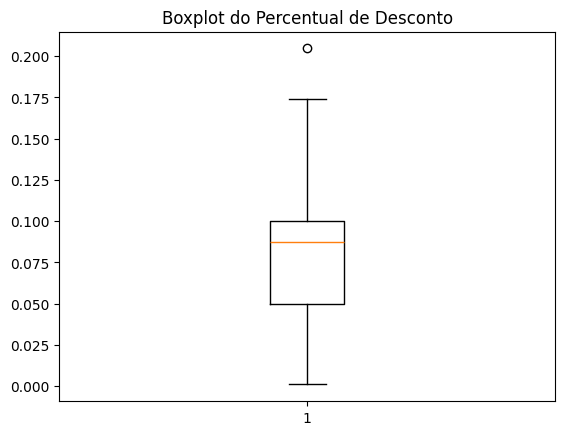

In [7]:
plt.boxplot(df_descontos["percentual_desconto"])
plt.title("Boxplot do Percentual de Desconto")

Vimos que a maioria dos descontos está na faixa de 5% à 10%, sugerindo de fato, que o percentual não é baseado no tamanho da venda.

Vamos analisar quem são aqueles pontos de atenção.

In [8]:
df[df["percentual_desconto"] > .1][["nome_fantasia", "percentual_desconto", "receita_prevista", "receita_realizada", "desconto"]]

,nome_fantasia,percentual_desconto,receita_prevista,receita_realizada,desconto
15,ART PÉ CALÇADOS,0.130435,27600.0,24000.00,3600.00
18,BALOO BABY KIDS TEENS,0.130435,13248.0,11520.00,1728.00
66,LARISSA MAZZONI,0.173913,8832.0,7296.00,1536.00
68,LEHUA,0.102610,32395.5,29071.39,3324.11
78,MAGIA DO MAR,0.204666,18860.0,15000.00,3860.00


Vamos salvar essas informações para caso mais pra frente for necessário.

Vamos analisar médias de receita para clientes que receberam desconto e que não receberam desconto

In [9]:
df["recebeu_desconto"] = df["percentual_desconto"] > 0
df.groupby("recebeu_desconto")[["receita_realizada", "area"]].mean()

,receita_realizada,area
recebeu_desconto,,
False,13409.428319,25.867257
True,18002.679545,34.750000


Temos uma diferença de aproximadamente R$ 5.000,00 na média e 10 m2.

A política de desconto faz total sentido, com faixas estruturadas no percentual de desconto de entre 5%-10%, apresentando descontos para vendas maiores.

Vamos analisar agora como é essa relação para o valor de metro quadrado de fato, isso é, a receita realizada / area, já que que recebe desconto paga mais e compra mais área.

In [10]:
df.groupby("recebeu_desconto")[["preco_m2"]].mean()

,preco_m2
recebeu_desconto,
False,570.188043
True,523.512533


Quem recebe desconto recebe R$ 50,00 a menos no metro quadrado.

### Conclusão

A análise dos descontos concedidos aos expositores mostrou que apenas uma pequena parcela dos clientes recebeu algum tipo de desconto. Ao comparar a receita média, observou-se que expositores que receberam desconto apresentam, em média, cerca de R$ 5.000 a mais de receita realizada em relação aos que não receberam desconto.

Entretanto, ao analisar o preço realizado por metro quadrado, verificou-se que os expositores com desconto pagam, em média, aproximadamente R$ 50 a menos por m2. Esse resultado indica que os descontos não estão necessariamente associados a negociações de baixo valor, mas sim a contratações de áreas maiores, onde preço por metro quadrado é reduzido para viabilizar o fechamento da venda.

Além disso, como uma pequena parcela dos expositores recebe desconto e o percentual concedido apresenta baixa variação (em geral 5% a 10%), os descontos não parecem ser o principal fator responsável pelas variações na receita total do evento.

Dessa forma, conclui-se que os descontos impactam o preço por metro quadrado, mas a receita total parece estar mais fortemente relacionada à área vendida, à taxa de ocupação (vacância) e ao preço base do metro quadrado do que propriamente à política de descontos.

## O preço médio por metro quadrado está alinhado com o esperado?

In [11]:
df["preco_m2_esperado"] = df["receita_prevista"] / df["area"]

df[["preco_m2", "preco_m2_esperado"]].describe()

,preco_m2,preco_m2_esperado
count,135.000000,135.000000
mean,562.581663,570.371590
std,84.726865,82.773023
min,87.719298,87.719298
25%,552.000000,552.000000
50%,552.000000,552.000000
75%,552.000000,552.000000
max,1007.400000,1007.400000


Com uma diferença de R$ 10, o preço realizado está praticamente alinhado com o preço previsto.

A equipe pode não estar errando na execução, ela pode estar errando na expectativa.

## A vacância de espaços impacta a receita de forma relevante?


In [12]:
query = "SELECT * FROM expositores_atual WHERE pipeline = 'ES_MAIO_26' AND tipo = 'STAND' and nome_fantasia = 'VACÂNCIA'"

df = pd.read_sql(query, engine)

df["receita_prevista"].sum()


np.float64(323953.85000000003)

Sabendo que faltam aproximadamente 600k para meta e que a receita esperada das vacâncias está em torno de 324k, quase metade do valor, podemos concluir que mesmo com 100% do evento fechado (com o preço cheio previsto das vacâncias) não bateríamos a meta.

A vacância impacta significativamente, porém não explica todo o gap da meta.

## Conclusão

A análise até aqui mostra que o problema não está simplesmente na existência de descontos, mas na qualidade das negociações realizadas. Os dados indicam que descontos, por si só, não comprometem a receita de forma relevante; no entanto, existe uma diferença clara entre negociações eficientes e ineficientes. Enquanto algumas vendas conseguem gerar alta receita com baixo nível de concessão, outras apresentam combinações desfavoráveis de alto desconto e baixo retorno. Isso sugere que o desafio não é reduzir descontos indiscriminadamente, mas entender onde eles são bem utilizados e onde estão destruindo valor. A partir disso, o foco deste estudo passa a ser a identificação dos perfis de expositores e padrões de negociação que maximizam a receita, permitindo direcionar o esforço comercial para oportunidades de maior retorno e reduzir a ocorrência de negociações pouco eficientes.

# Quais clientes devemos focar?

In [70]:
query = "SELECT * FROM expositores_atual WHERE pipeline = 'ES_MAIO_26' AND tipo = 'STAND' and nome_fantasia != 'VACÂNCIA'"

df = pd.read_sql(query, engine)
df = df[df["receita_realizada"].notna()]

df["desconto"] = df["receita_prevista"] - df["receita_realizada"]
df["preco_m2"] = df["receita_realizada"] / df["area"]
df["percentual_desconto"] = df["desconto"] / df["receita_prevista"] 


df = df[(df['percentual_desconto'] != 1) & (df['percentual_desconto'] >= 0)]
df[df["percentual_desconto"] > .1][["nome_fantasia", "percentual_desconto", "receita_prevista", "receita_realizada", "desconto", "categoria"]]

,nome_fantasia,percentual_desconto,receita_prevista,receita_realizada,desconto,categoria
15,ART PÉ CALÇADOS,0.130435,27600.0,24000.00,3600.00,CALÇADOS E BOLSAS MULTIMARCAS
18,BALOO BABY KIDS TEENS,0.130435,13248.0,11520.00,1728.00,MULTIMARCAS INFANTIL
66,LARISSA MAZZONI,0.173913,8832.0,7296.00,1536.00,MODA FEMININA
68,LEHUA,0.102610,32395.5,29071.39,3324.11,MODA MASCULINA
78,MAGIA DO MAR,0.204666,18860.0,15000.00,3860.00,MODA PRAIA E FITNESS


Esses foram os expositores com negociações preocupantes, sabemos que 22 expositores efetivamente receberam desconto, desses 22, apenas 5 foram "mal negociados", aproximadamente 23% das negociações.

Por mais que evitar que 23% de negociações mal feitas não faria com que a meta fosse batida de fato, podemos juntar também com a eliminação de vacâncias e talvez teríamos, de fato, uma resposta.

In [14]:
df_descontos = df[df["percentual_desconto"] > 0]

df_descontos["negociacao_ruim"] = ((df_descontos["percentual_desconto"] > .1))

df_descontos.groupby("negociacao_ruim")[["percentual_desconto", "receita_realizada"]].mean()


,percentual_desconto,receita_realizada
negociacao_ruim,,
False,0.066823,18186.562353
True,0.148412,17377.478000


Isso mostra que "negociações ruins" têm praticamente o dobro de desconto e mil reais a menos de receita na média.

In [15]:
import plotly.express as px

px.scatter(df_descontos, x="percentual_desconto", y="receita_realizada", color="negociacao_ruim", title="Relação entre Percentual de Desconto e Receita Realizada")

In [16]:
from unidecode import unidecode

df_descontos["cidade"]= df_descontos["cidade"].apply(unidecode)

df_descontos["cidade"].value_counts()

cidade
VITORIA                  8
SERRA                    6
VILA VELHA               4
JARDIM CAMBURI           1
NOVA FRIBURGO RJ         1
CARIACICA                1
SANTA MARIA DE JETIBA    1
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df_descontos[["recorrente", "cidade", "area"]]
y = df_descontos["negociacao_ruim"]

transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['cidade'])
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_encoded = transformer.fit_transform(X_train)
X_test_encoded = transformer.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00         4
        True       0.20      1.00      0.33         1

    accuracy                           0.20         5
   macro avg       0.10      0.50      0.17         5
weighted avg       0.04      0.20      0.07         5



c:\Users\KauãDias\Documents\sales_analyses\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KauãDias\Documents\sales_analyses\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KauãDias\Documents\sales_analyses\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [24]:
import numpy as np

coef_df = pd.DataFrame({
    'Variável': transformer.get_feature_names_out(),
    'Coeficiente': model.coef_[0]
})
coef_df.sort_values(by='Coeficiente', ascending=False, inplace=True)

coef_df["odds_ratio"] = np.exp(coef_df["Coeficiente"])

coef_df["Efeito"] = np.where(coef_df["odds_ratio"] > 1, "Aumenta chance de negociação ruim", "Diminui chance de negociação ruim")

coef_df[["Variável", "Efeito"]]

,Variável,Efeito
1,onehot__cidade_JARDIM CAMBURI,Aumenta chance de negociação ruim
4,onehot__cidade_VILA VELHA,Aumenta chance de negociação ruim
5,onehot__cidade_VITORIA,Aumenta chance de negociação ruim
6,remainder__recorrente,Aumenta chance de negociação ruim
7,remainder__area,Diminui chance de negociação ruim
0,onehot__cidade_CARIACICA,Diminui chance de negociação ruim
2,onehot__cidade_SANTA MARIA DE JETIBA,Diminui chance de negociação ruim
3,onehot__cidade_SERRA,Diminui chance de negociação ruim


Negociações mais agressivas tendem a ocorrer com:
 - Clientes recorrentes;
 - Expositores de maior área
 - Perfis específicos de localização

Os resultados são indicativos e devem ser usados como apio à decisão, não como regra definitiva.

In [25]:
df_descontos.groupby("negociacao_ruim")[["area"]].mean()

,area
negociacao_ruim,
False,33.941176
True,37.500000


O resultado acima mostra exatamente como o modelo pode ser mal interpretado.

### Conclusão

Descontos não são o principal problema, pois seguem um padrão consistente e estão concentrados em uma faixa relativamente controlada. Além disso, apenas uma pequena parcela das negociações com desconto pode ser considerada de fato subótima.

As negociações mal conduzidas tendem a se concentrar em expositores recorrentes e com maior área contratada, indicando maior poder de barganha nesses perfis.

Embora algumas cidades apareçam associadas a esse comportamento, não há evidência de relação causal direta. O efeito observado pode ser explicado pelo fato de regiões com maior poder econômico concentrarem expositores de maior porte, o que indiretamente influencia as condições de negociação.

## Otimização de Receita via Composição do Mix de Expositores

Nesta seção, será analisado como o porte dos expositores impacta a formação da receita.

A ideia é segmentar os expositores por tamanho e comparar métricas como receita e valor por metro quadrado, buscando entender o papel da composição do mix de clientes no resultado final. 

In [29]:
# Vamos segmentar pelo quartil da área

df["porte"] = pd.qcut(df["area"], q=3, labels=["Pequeno", "Médio", "Grande"])

df["porte"].value_counts()

porte
Pequeno    55
Grande     43
Médio      37
Name: count, dtype: int64

Bem equilibrado.

In [31]:
df.groupby("porte").agg({"area": "mean",
                         "receita_realizada": "mean",
                         "preco_m2": "mean",
                         "percentual_desconto": "mean"}).round(2)

,area,receita_realizada,preco_m2,percentual_desconto
porte,,,,
Pequeno,14.55,8201.32,568.82,0.01
Médio,21.65,11968.42,552.81,0.01
Grande,48.52,23660.94,563.01,0.03


Expositores de grande porte geram mais receita total devido à maior área, mesmo com menor valor por metro quadrado e leve aumento nos descontos.

Já os de pequeno porte apresentam maior eficiência por m2. Isso evidencia um trade-off entre volume (grandes) e eficiência (pequenos).

In [35]:
(df.groupby("porte")[["receita_realizada"]].sum() / df["receita_realizada"].sum() * 100).round(2)

,receita_realizada
porte,
Pequeno,23.60
Médio,23.17
Grande,53.23


A receita está concentrada em expositores de grande porte, que representam mais da metade do total.

Pequenos e médios contribuem de forma semelhante, reforçando a importância estratégica dos grandes na geração de receita.

Expositores de médio porte apresentam menor valor por m2, mesmo com descontos semelhantes aos pequenos, indicando possível ineficiência na precificação desse segmento.

Isso sugere que não aproveitam nem o ganho de volume dos grandes nem a eficiência de preço dos pequenos, podendo também refletir diferenças de localização ou da amostra.

O segmento médio apresenta o pior custo-benefício dos dados: paga menos por m2 que os pequenos, não escala como os grandes e, no agregado, entrega praticamente o mesmo resultado que os pequenos.

isso indica uma ineficiência clara na alocação de espaço e na estratégia de negociação.

### Simulação Mix De Porte

Vamos simular cenários de redução de stands de porte médio e redistribuir para os outros portes.

In [58]:
pequenos = len(df[df["porte"] == "Pequeno"])
medios = len(df[df["porte"] == "Médio"])
grandes = len(df[df["porte"] == "Grande"])

# Médias por porte
area_pequenos = df[df["porte"] == "Pequeno"]["area"].mean()
area_medios = df[df["porte"] == "Médio"]["area"].mean()
area_grandes = df[df["porte"] == "Grande"]["area"].mean()

v_m2_pequenos = df[df["porte"] == "Pequeno"]["preco_m2"].mean()
v_m2_medios = df[df["porte"] == "Médio"]["preco_m2"].mean()
v_m2_grandes = df[df["porte"] == "Grande"]["preco_m2"].mean()

receita_total_atual = df["receita_realizada"].sum()

reducoes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for r in reducoes:
    medios_novos_qtd = int(medios * (1 - r))
    removidos_qtd = medios - medios_novos_qtd

    # Receita fixa dos que sobraram Médios e dos Pequenos originais
    receita_base_medios = medios_novos_qtd * (area_medios * v_m2_medios)
    
    # --- Cenário 1: Médios viram Grandes ---
    # Eles ganham a área média de um grande e o valor_m2 de um grande
    grandes_totais_qtd = grandes + removidos_qtd
    receita_grandes_simulada = grandes_totais_qtd * (area_grandes * v_m2_grandes)
    receita_pequenos_estatica = pequenos * (area_pequenos * v_m2_pequenos)
    
    nova_receita_c1 = receita_grandes_simulada + receita_base_medios + receita_pequenos_estatica

    # --- Cenário 2: Médios viram Pequenos ---
    pequenos_totais_qtd = pequenos + removidos_qtd
    receita_pequenos_simulada = pequenos_totais_qtd * (area_pequenos * v_m2_pequenos)
    receita_grandes_estatica = grandes * (area_grandes * v_m2_grandes)

    nova_receita_c2 = receita_grandes_estatica + receita_base_medios + receita_pequenos_simulada

    print(f"Redução de {int(r*100)}% dos Médios:")
    print(f"  Cenário 1 (Viram Grandes): {nova_receita_c1:.2f} (Var: {((nova_receita_c1/receita_total_atual)-1)*100:.2f}%)")
    print(f"  Cenário 2 (Viram Pequenos): {nova_receita_c2:.2f} (Var: {((nova_receita_c2/receita_total_atual)-1)*100:.2f}%)")
    print("-" * 50)

Redução de 10% dos Médios:
  Cenário 1 (Viram Grandes): 2133984.04 (Var: 11.65%)
  Cenário 2 (Viram Pequenos): 2057802.63 (Var: 7.66%)
--------------------------------------------------
Redução de 20% dos Médios:
  Cenário 1 (Viram Grandes): 2195389.83 (Var: 14.86%)
  Cenário 2 (Viram Pequenos): 2043027.00 (Var: 6.89%)
--------------------------------------------------
Redução de 30% dos Médios:
  Cenário 1 (Viram Grandes): 2256795.62 (Var: 18.07%)
  Cenário 2 (Viram Pequenos): 2028251.37 (Var: 6.12%)
--------------------------------------------------
Redução de 40% dos Médios:
  Cenário 1 (Viram Grandes): 2302849.96 (Var: 20.48%)
  Cenário 2 (Viram Pequenos): 2017169.65 (Var: 5.54%)
--------------------------------------------------
Redução de 50% dos Médios:
  Cenário 1 (Viram Grandes): 2364255.75 (Var: 23.70%)
  Cenário 2 (Viram Pequenos): 2002394.03 (Var: 4.76%)
--------------------------------------------------
Redução de 60% dos Médios:
  Cenário 1 (Viram Grandes): 2425661.54 (Va

A análise indica que o problema não está  na distribuição de expositores por porte, mas na inconsistência da precificação ao longo da área contratada.

Observa-se que expositores de médio porte apresentam valor por metro quadrado inferior ao esperado, dado seu tamanho, sem que haja ganho proporcional em volume de receita.

Isso sugere que a política atual de precificação não segue uma lógica contínua em relação à área, gerando ineficiências especialmente no segmento intermediário.

Dessa forma, recomenda-se a revisão da curva de preço por metro quadrado, buscando alinhar o valor cobrado ao tamanho do expositor de forma mais consistente. 

Considerando a relação esperada entre área e valor por metro quadrado, espera-se que os expositores de médio porte apresentem preços intermediários entre pequenos e grandes.

No entanto, observa-se que o valor praticado para esse segmento está significativamente abaixo desse intervalo, indicando subprecificação.

Uma estimativa simples sugere que o preço médio por metro quadrado dos expositores médios deveria estar em torno de um valor intermediário entre pequenos e grandes, o que não se verifica na prática.

Esse desvio representa uma oportunidade direta de aumento de receita sem necessidade de expansão de área.

In [68]:
media_ideal = (df[df["porte"] == "Grande"]["preco_m2"].mean() + df[df["porte"] == "Pequeno"]["preco_m2"].mean()) / 2

receita_potencial_medio = df[df["porte"] == "Médio"]["area"].sum() * media_ideal

ganho_receita = receita_potencial_medio - df[df["porte"] == "Médio"]["receita_realizada"].sum()

impacto_possivel_medio = receita_potencial_medio / (df["receita_realizada"].sum() + ganho_receita) * 100

print(f"Receita Potencial dos Médios: {receita_potencial_medio:.2f}")
print(f"Ganho de Receita: {ganho_receita:.2f}")
print(f"Impacto Possível dos Médios: {impacto_possivel_medio:.2f}%")

Receita Potencial dos Médios: 453297.52
Ganho de Receita: 10466.02
Impacto Possível dos Médios: 23.59%


O porte médio apresenta subprecificação, mas corrigir esse ponto gera impacto marginal na receita (>1%).

Isso indica que o problema não está em ajustes de preço, mas em fatores estruturais, como o mix de expositores e a definição de meta.

# Conclusão 

A análise dos dados evidencia que o não atingimento da meta não está associado a falhas pontuais, mas a aspectos estruturais da estratégia comercial. Nesse contexto, recomenda-se a formalização de uma política de descontos, com critérios mais claros por perfil de expositor, a fim de reduzir o risco de concessões desproporcionais, especialmente em negociações com clientes recorrentes e de grande porte, onde há maior poder de barganha.

Além disso, os resultados indicam a necessidade de revisão na forma como a meta é definida, uma vez que o modelo atual se aproxima mais de um valor máximo teórico do que de uma meta operacional realista.

Por fim, destaca-se a ineficiência do segmento de médio porte, que não captura plenamente nem os ganhos de escala dos grandes nem a eficiência de preço dos pequenos. Nesse sentido, propõe-se a redução da tolerância a esse perfil, seja por meio de ajustes na precificação do metro quadrado ou pelo direcionamento estratégico desses expositores para áreas menores ou maiores, alinhando-os a modelos mais eficientes de geração de receita.

Em conjunto, essas ações permitem uma abordagem mais estruturada e alinhada à dinâmica real do negócio, com maior potencial de otimização de receita em eventos futuros.